In [2]:
%load_ext autoreload
%autoreload 2

# 一.数值求解能谱和本征态
## 1.流程：矩阵化
- 截断空间范围：选取$x \in [x_{min}, x_{max}]$，满足势能在边界处足够大，保证波函数在边界处接近零。
- 离散化空间：将空间划分为$N$个等距点，定义网格点为$x_i = x_{min} + i \Delta x$，其中$i=0,1,...,N-1$，$\Delta x = \frac{x_{max} - x_{min}}{N-1}$。
- 构建哈密顿矩阵：使用有限差分方法近似动能算符，势能项直接在对角线上表示。势能项为$V = V(x_i)$，动能项的二阶中心差分近似为：
$$\hat{T} \psi(x_i) \approx -\frac{\hbar^2}{2m} \frac{\psi(x_{i+1}) - 2\psi(x_i) + \psi(x_{i-1})}{\Delta x^2}$$
- 最终的哈密顿矩阵为：$ H = T + V $，能谱和本征态的求解归结为求解矩阵特征值问题。

## 2.可视化
绘制曲线$ y_n = E_n + \alpha \psi_n(x)$，其中$\alpha$为一个缩放因子，用于调整波函数的可视化效果。如图：

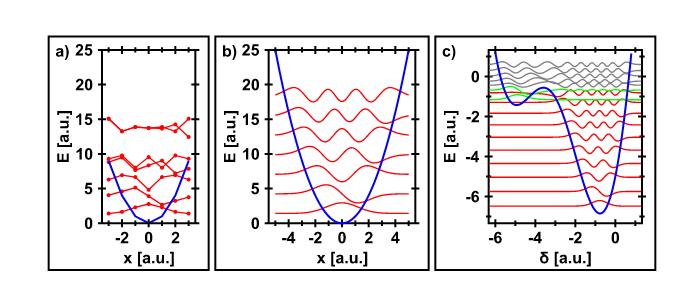

从图中可以得到以下信息：
- 节点数和振荡情况：第$n$个本征态$\psi_n(x)$具有$n$个节点，随着能量的增加，波函数的振荡频率也增加。
- 与$V(x)$比较：能级$E_n$大于势能$V(x)$的区域，波函数表现为振荡；而在$E_n < V(x)$的区域，波函数表现为指数衰减。

## 3.误差与复杂度
- 截断误差：由于空间范围的限制，可能会遗漏高能态或边界效应，导致能谱和本征态的误差。
- 差分误差：有限差分方法引入的近似误差，尤其在高能态或较粗的网格上更为显著。
- 计算复杂度：求解$N \times N$矩阵的特征值问题通常具有$O(N^3)$的计算复杂度，随着网格点数的增加，计算时间显著增加。

## 4.对数值结果的分析
- 判断工作势阱是否支持两个局域态：$\psi_n$主要在工作势阱附近；$E_n$低于势阱的最低能级时，该态为局域态。
- 计算工作频率
- 计算非简谐性
- 双势阱读出机制：
    - 将势能分为左阱（工作阱）和右阱（读出阱），右阱更深，支持更多能级。测量时会短暂改变外参，使得左阱到右阱的隧穿对某个态更容易。
    - 该态在隧穿后会落到右阱中最接近原能级的态上，落到的态越高，弛豫越快。
    - 弛豫后落到更低的态，从而实现锁存，不容易隧穿回来。

## 5.收敛性和可信性


## 6.扩展到耦合量子比特

---

下面用以上方法求Transmon qubit的能谱和本征态。
相位表象下，Transmon qubit的哈密顿量为$$H = -4E_C (-i\frac{\partial}{\partial \varphi}-n_g)^2 - E_J \cos \varphi$$其中，$E_C$通常取为0.2GHz，$E_J$取为10GHz。通过数值求解，可以得到Transmon qubit的能谱和本征态，并分析其非简谐性和工作频率等特性。

为了除去$n_g$，作规范变换$\psi(\varphi) = e^{i n_g \varphi} \phi(\varphi)$，则哈密顿量变为$$H = -4E_C (-i\frac{\partial}{\partial \varphi})^2 - E_J \cos \varphi$$其中，$n_g$为偏置电荷数。该变换消除了相位表象下的偏置项，简化了数值计算，代价是改变了边界条件。物理上要求原来的波函数单值，则$\psi(\varphi + 2\pi) = \psi(\varphi)$。因此，变换后的波函数满足$\phi(\varphi + 2\pi) = e^{-i 2\pi n_g} \phi(\varphi)$，即具有一个相位因子。这种边界条件反映了偏置电荷对系统的影响，导致能谱和本征态的变化。通过数值求解变换后的哈密顿量，可以分析不同$n_g$值下Transmon qubit的能谱特性。

有磁通的情况下，Josephson能量$E_J$变为$E_J(\Phi) = E_J \cos(\pi \Phi/\Phi_0)$，其中$\Phi_0 = h/2e$为磁通量子。


E (GHz): [-16.90154382 -10.83809584  -5.05205068   0.43239618   5.58114914
  10.35802823  14.55752287  18.77846104]
f01 = 6.063448 GHz, f12 = 5.786045 GHz, anh = -0.277403 GHz


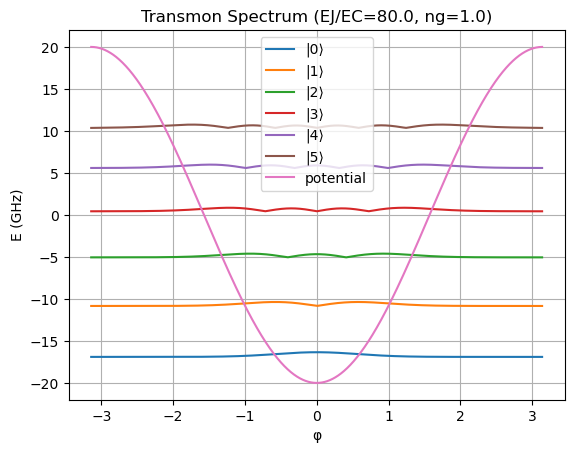

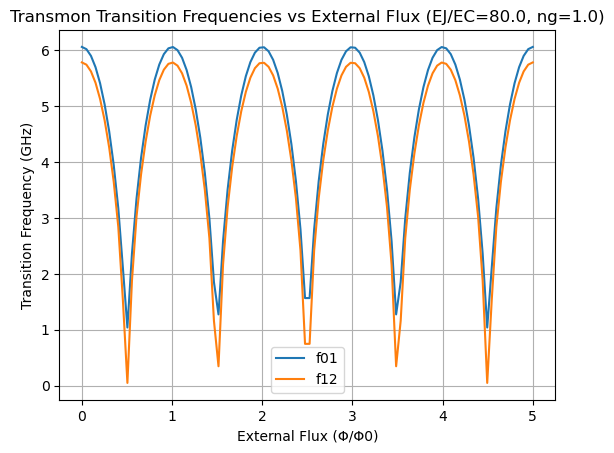

In [3]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt


def transmon_spectrum_phase(EJ, EC, N=2000, k=10, ng=0.0, Phi = 0.0):
    """
    用相位表象(φ网格)求transmon能谱：
        H = 4EC (n - ng)^2 - EJ cos φ
    在φ表象中，(n - ng) 等效为扭曲边界条件：
        ψ(φ+2π) = exp(i 2π ng) ψ(φ)

    参数
    ----
    EJ, EC : float
        以频率单位输入(例如 GHz)，即 EJ/h, EC/h
    N : int
        φ网格点数，越大越精确
    k : int
        求最低k个本征值
    ng : float
        offset charge (单位：2e)，范围通常 [0, 1)

    返回
    ----
    evals : (k,) ndarray
        最低k个本征值(单位同EJ/EC，比如 GHz)
    evecs : (N, k) ndarray
        对应的本征矢(φ网格波函数)
    phi : (N,) ndarray
        φ网格
    """
    EJ_eff = EJ * np.cos(np.pi * Phi)  # 考虑外磁通对EJ的调制
    # φ网格：一个周期
    phi = np.linspace(-np.pi, np.pi, N, endpoint=False)
    dphi = 2 * np.pi / N

    # 二阶导数矩阵 D (周期边界 + 扭曲相位)
    main = (-2.0 / dphi**2) * np.ones(N)
    off = (1.0 / dphi**2) * np.ones(N - 1)

    D = sp.diags([off, main, off], offsets=[-1, 0, 1], format="lil", dtype=complex)

    # 扭曲边界：跨边界的“绕回”项带相位
    twist = np.exp(1j * 2 * np.pi * ng)
    D[0, N - 1] = (1.0 / dphi**2) * np.conj(twist)   # e^{-i2πng}
    D[N - 1, 0] = (1.0 / dphi**2) * twist            # e^{+i2πng}

    D = D.tocsr()

    # 势能对角项
    V = sp.diags(-EJ_eff * np.cos(phi), 0, format="csr", dtype=complex)

    # 哈密顿量：T = -4EC d^2/dφ^2
    H = (-4.0 * EC) * D + V

    # 求最低k个本征值（smallest algebraic）
    evals, evecs = spla.eigsh(H, k=k, which="SA")
    idx = np.argsort(evals)
    evals = np.real(evals[idx])
    evecs = evecs[:, idx]

    return evals, evecs, phi


if __name__ == "__main__":
    EJ = 20.0   # GHz
    EC = 0.25   # GHz  -> EJ/EC=80
    ng = 1.0
    Phi = 0.0   # 无外磁通
    evals, evecs, phi = transmon_spectrum_phase(EJ, EC, N=2000, k=8, ng=ng, Phi=Phi)

    print("E (GHz):", evals)
    f01 = evals[1] - evals[0]
    f12 = evals[2] - evals[1]
    anh = f12 - f01
    V = -EJ * np.cos(phi)
    print(f"f01 = {f01:.6f} GHz, f12 = {f12:.6f} GHz, anh = {anh:.6f} GHz")
    plt.plot(phi, evals[0]+10 * np.abs(evecs[:, 0]) , label="|0⟩")
    plt.plot(phi, evals[1]+10 * np.abs(evecs[:, 1]) , label="|1⟩")
    plt.plot(phi, evals[2]+10 * np.abs(evecs[:, 2]) , label="|2⟩")
    plt.plot(phi, evals[3]+10 * np.abs(evecs[:, 3]) , label="|3⟩")
    plt.plot(phi, evals[4]+10 * np.abs(evecs[:, 4]) , label="|4⟩")
    plt.plot(phi, evals[5]+10 * np.abs(evecs[:, 5]) , label="|5⟩")
    plt.plot(phi, V , label="potential")
    plt.xlabel("φ")
    plt.ylabel("E (GHz)")
    plt.title(f"Transmon Spectrum (EJ/EC={EJ/EC}, ng={ng})")
    plt.legend()
    plt.grid()
    plt.show()

    Phi_list = np.linspace(0, 5, 100)  # 外磁通从0到1个Φ0
    f01_list = []
    f12_list = []
    for Phi in Phi_list:
        evals, _, _ = transmon_spectrum_phase(EJ, EC, N=1000, k=3, ng=ng, Phi=Phi)
        f01 = evals[1] - evals[0]
        f12 = evals[2] - evals[1]
        f01_list.append(f01)
        f12_list.append(f12)

    
    plt.plot(Phi_list, f01_list, label="f01")
    plt.plot(Phi_list, f12_list, label="f12")
    plt.xlabel("External Flux (Φ/Φ0)")
    plt.ylabel("Transition Frequency (GHz)")
    plt.title(f"Transmon Transition Frequencies vs External Flux (EJ/EC={EJ/EC}, ng={ng})")
    plt.legend()
    plt.grid()
    plt.show()

# 二.qubit控制
系统波函数可以写成$H_0$本征态的叠加：
$$\ket{\psi(t)} = \sum_n c_n(t) e^{-i E_n t/\hbar} \ket{n}$$
其中$c_n$与跃迁矩阵元$\langle m | V | n \rangle$有关。

可以写成微分方程的形式：
$$i \hbar \frac{d}{dt} c_m(t) = \sum_n \langle m | V(t) | n \rangle c_n(t) e^{i (E_m - E_n) t/\hbar}$$
具体的，外部驱动通过输入电流信号来调制，flux qubit势能随偏置电流的响应具体表现为$V(t) = -\frac{\Phi_0}{2 \pi}\Delta I(t)\varphi$。则跃迁矩阵元为：
$$\langle m | V(t) | n \rangle = -\frac{\Phi_0}{2 \pi} \Delta I(t) \langle m | \varphi | n \rangle = \Delta I(t)T_{mn}$$

对于Transmon qubit，控制信号有两种常见形式：
- 电容耦合：通过调制电压信号来控制，跃迁矩阵元为$\langle m | V(t) | n \rangle = 2e  V_e(t) \langle m | n | n \rangle$，其中$n$为库仑数算符。
- 频率调制：通过调制外磁通来控制，跃迁矩阵元为$\langle m | V(t) | n \rangle = -\frac{\Phi_0}{2 \pi} \Delta \Phi(t) \langle m | \cos \varphi | n \rangle$。

## 1.Bloch球上的转动
对于电容耦合的控制信号，实验上常使用近共振微波信号实现对qubit的控制：$$V_d = A(t) \cos \omega_d t + \phi$$
在RWA近似下，旋转系下有效哈密顿量为$$ H_{eff} = \frac{1}{2} \Delta \sigma_z + \frac{1}{2} \Omega(t) (\sigma_x \cos \phi + \sigma_y \sin \phi)$$
则旋转轴为$$\hat{n} = (\Omega(t) \cos \phi, \Omega(t) \sin \phi, \Delta)$$
在共振条件下，调整$\phi$可以实现绕不同轴的旋转，从而实现XY单比特门操作。

对于Z单比特门，有虚拟Z门和物理Z门两种实现方式：
- 虚拟Z门：通过将后续所有作用在该qubit的驱动脉冲相位整体平移$\phi$，从而实现虚拟Z门操作。
- 物理Z门：通过调制外磁通来实现频率调制，从而实现物理Z门操作。
## 2.单比特系统
在$\omega_d$旋转系中，RWA近似下的Transmon qubit总哈密顿量为$$H_{rot} = \frac{\Delta}{2} a^\dagger a + \frac{\alpha}{2} a^\dagger a^{\dagger}a a + \frac{1}{2} \Omega(t) (a e^{i\phi}+ a^\dagger e^{-i \phi})$$
### 2.1 DRAG脉冲
Transmon qubit是多能级系统，强脉冲下会发生能级泄露，以及AC stark位移等问题，DRAG将Transmon qubit截断到三能级，通过在同一个微波脉冲中同时设计I/Q两个正交分量来补偿这些问题，从而实现更高保真度的单比特门操作。
使用IQ混频微波信号$$V_d = I(t) \cos \omega_d t - Q(t) \sin \omega_d t$$
旋转系下，哈密顿量为$$H_{drive} = \frac{1}{2}(\Omega_I S_x + \Omega_Q S_y) $$
DRAG脉冲设计为$$\Omega_I(t) = \Omega_0 f(t) \, \, \Omega_Q(t) = -\beta \frac{d f(t)}{dt}\Omega_I(t)$$
导数项可以在一阶近似下抵消高能级泄露。

除了导数项，DRAG还加了一个小失谐$\delta$，则$$\omega_d = \omega_{01} + \delta$$
### 2.2 单比特门仿真
参数设置：
- 能级截断数N
- Transmon qubit参数：$E_C$, $E_J$
- 脉冲参数：$\phi$/$\Omega_I、\Omega_Q$，$T$

时间演化：
* 无耗散 
    - 计算时间演化算符：$$U(t) = \mathcal{T} e^{-i \int_0^t H_{rot}(t') dt'}$$
* 有耗散
    - 使用Lindblad主方程：$$\frac{d\rho}{dt} = -i[H_{rot}, \rho] + \sum_k \gamma_k (L_k \rho L_k^\dagger - \frac{1}{2} \{L_k^\dagger L_k, \rho\})$$
    - 其中$L_k$为耗散算符，$\gamma_k$为对应的耗散率。

结果分析：
- 能级泄露：
- 保真度：
## 3.耦合系统
### 3.1 电容耦合
两个Transmon qubit之间的电容耦合可以通过两岛之间的耦合电容$C_c$来实现，耦合项为$$H_{int} = g (a_1 a_2^\dagger + a_1^\dagger a_2)$$
有两种基表示法：
- bare basis：$\ket{ij}$
- dressed basis：$H_0$的本征态$\ket{\tilde{n}}$，其中$H_0 = H_{rot,1} + H_{rot,2}$

两个工作区间（$\Delta = \omega_1 - \omega_2$）：
- 近共振区间：$|\Delta| \lesssim g$
- 色散区间：$|\Delta| \gg g$
### 3.2 iSWAP门
在bare基下，iSWAP门的作用矩阵为$$U_{iSWAP} = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 0 & i & 0 \\ 0 & i & 0 & 0 \\ 0 & 0 & 0 & 1 \end{pmatrix}$$
相较于SWAP门，iSWAP门在交换$\ket{01}$和$\ket{10}$的同时引入了一个相位因子$i$，这使得iSWAP门在某些量子算法中具有独特的优势，使得iSWAP门为纠缠门（将非纠缠态转化为纠缠态）。

在Transmon qubit中，交换哈密顿量可以写为$$H_{int} = g (a_1 a_2^\dagger + a_1^\dagger a_2) \approx g(\sigma_+^1 \sigma_-^2 + \sigma_-^1 \sigma_+^2) = \frac{1}{2}(\sigma_x^1 \sigma_x^2 + \sigma_y^1 \sigma_y^2)$$
在子空间$\{\ket{01}, \ket{10}\}$中，交换哈密顿量的作用为$$H_{int} = g \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix} = g \sigma_x$$
则时间演化为$$U(t) = e^{-i H_{int} t} = \cos(gt) I - i \sin(gt) \sigma_x$$
当$gt = \pi/2$时，得到iSWAP门，对于一些单比特相位的偏移，可以用虚拟Z门进行补偿。

实验上通常有三种方案实现iSWAP门：
- 对于两个可调频的Transmon qubit，在空闲时，将频率调至色散区，则交换被抑制（但存在ZZ），门操作时，改变一个或两个qubit的频率至近共振区间，停留$t = \frac{\pi}{2g}$，实现iSWAP门。
- 可调耦合器：在两个qubit中间引入一个可调频的qubit，通过调节耦合器的参数来控制交换强度$g_{eff}$，在门操作时，将$g$调至适当值，停留$t = \frac{\pi}{2g}$，实现iSWAP门。
- 参数调制（parametric iSWAP）：两qubit位于色散区域
### 3.3 CZ门
在bare基下，CZ门的作用矩阵为$$U_{CZ} = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & -1 \end{pmatrix}$$
实验上，CZ门可能会有一定的非理想性，表现为对角但带相位的门$$U_{CZ}' = \begin{pmatrix} e^{i\phi_0} & 0 & 0 & 0 \\ 0 & e^{i\phi_1} & 0 & 0 \\ 0 & 0 & e^{i\phi_2} & 0 \\ 0 & 0 & 0 & e^{i\phi_3} \end{pmatrix}$$
利用虚拟Z门，对两个比特分别施加一个Z旋转，可以消除$\phi_1, \phi_2$，定义条件相位为$\phi_{CZ} = \phi_0 - \phi_1 -\phi_2 - \phi_3$（其定义来源于对原矩阵分别作全局相位消除，两个比特作虚拟Z门旋转得到），$\phi_{CZ}$为$\pi$时，为理想CZ门。

在Transmon qubit中，在电容耦合下，$\ket{11}$和$\ket{02}$之间的耦合强度为$\sqrt{2}g$，当调节某个qubit的频率，使得系统经历一个绝热演化，使得从态$ket{11}$，绝热地历经$\ket{02}$，再回到\ket{11}$，从而使得$\ket{11}$积累一定的几何相位。

在子空间$\{\ket{11}, \ket{02}\}$中，一定的旋转系下，哈密顿量为$$H_{sub} = \begin{pmatrix} 0 & \sqrt{2}g \\ \sqrt{2}g & \delta(t)  \end{pmatrix}$$
当$\delta = 0$时，初态$\ket{11}$发生Rabi振荡，Rabi频率为$\sqrt{2}g$，当停留时间$t = \frac{\pi}{\sqrt{2}g}$时，$\ket{11}$积累一个$\pi$的相位，得到CZ门。

除了上述方案，当两比特处于色散区域是，可以利用ZZ相互作用来实现CZ门。通过可调耦合器或者对频率参数调制，可以得到可控的ZZ强度$\zeta$，在门操作时，调节ZZ强度，使得$\varphi = \int_0^{t} \zeta dt = \pi$，从而实现CZ门。
### 3.4 CR门
CR门主要用于固定频率的Transmon qubit。在实现CNOT门时，选定一个qubit作为控制比特c，另一个qubit为目标比特t，在c上施加脉冲驱动$H_d = \Omega(t)\cos(\omega_d t + \phi)(a_c + a_c^\dagger)$，由于两比特之间的耦合，t上会有一个有效驱动。c的状态不同，有效驱动强度会不一样，因此会产生一个条件驱动ZX项。在一定的旋转系下，系统哈密顿量为$$H_{eff} = \frac{1}{2}[\Omega_{IX}(t)IX + \Omega_{IY}(t)IY + \Omega_{ZX}(t)ZX + \Omega_{ZY}(t)ZY + \Omega_{ZI}(t)ZI + \Omega_{ZZ}(t)ZZ]$$其中ZX项为条件控制项，ZI项为c的AC stark位移，ZZ项为c和t之间的条件频移。

通过调整参数，使得ZX项的时间演化为$$U_{ZX} = e^{-i \frac{\theta}{2}ZX} $$其中，$\theta = \Omega_{ZX} t = \frac{\pi}{2}$，得到了$ZX_{\frac{\pi}{2}}$后，可以通过一系列单比特门，得到CNOT门，具体步骤为$ZX_{\frac{\pi}{2}} \rightarrow ZZ_{\frac{\pi}{2}} \rightarrow CZ \rightarrow  CNOT$：
- 在t后施加一个H门，将ZX项转化为ZZ项
- 施加一个S门，将ZZ项转化为CZ项，$S = diag(1,i)$
- 施加一个H门，将CZ项转化为CNOT门
则有$$CNOT = (I \otimes H) (S^{\dagger} \otimes S^{\dagger})e^{i\frac{\pi}{4} }e^{-i \frac{\pi}{4} ZX} (I \otimes H) $$

另一种方法是：
- 给t施加一个$R_x(-\frac{\pi}{2})$门
- 给c施加一个S门

由于只打一段CR脉冲，会积累大量IX、IY、ZI等不需要的误差，因此通常会在CR脉冲前后加上补偿脉冲来抵消这些项，从而得到更高保真度的CNOT门：
- 先打一段CR脉冲
- 对控制比特施加一个$\pi$的X门，翻转控制比特的状态
- 再打一段CR脉冲，此时由于控制比特状态翻转，之前积累的IX、IY、ZI等误差项会被抵消掉，从而得到一个更纯净的ZX项，最后通过单比特门补偿掉剩余的ZZ项，得到更高保真度的CNOT门。
### 3.5 ZZ
考虑bare基下的本征值$E_{00} = 0, E_{01} = \omega_2, E_{10} = \omega_1, E_{11} = \omega_1 + \omega_2 $，定义ZZ强度为$\hbar\zeta = E_{11} - E_{10} - E_{01} + E_{00}$，其可理解为qubit1在qubit2不同状态下的跃迁频率差，因此也可以称为条件频移。

考虑$\ket{2}$相关本征值$E_{20} = 2\omega_1 + \alpha_1, E_{02} = 2\omega_2 + \alpha_2$，用二阶微扰论公式：$$\delta E_n = \sum_{m \neq n} \frac{|\langle m | H_{int} | n \rangle|^2}{E_m - E_n}$$
则本征态的二阶能量修正为$$\delta E_{00} = 0, \delta E_{10} = - \frac{g^2}{E_{01} - E_{10}}, \delta E_{01} = \frac{g^2}{E_{01} - E_{10}}, \delta E_{11} = -\frac{2g^2}{E_{20} - E_{11}} - \frac{2g^2}{E_{02} - E_{11}}$$
代入能量修正，可以得到ZZ强度为$\zeta = \delta E_{11}$，在色散区域，不同能级之间的交换被抑制，可以将哈密顿量按照bare基展开成对角形式，则有$$H = \omega_1 n_1 + \omega_2 n_2 + \zeta n_1 n_2 + const $$
利用公式$\sigma_z = 2 n - 1$，则哈密顿量写为$$H = \frac{\omega_1}{2}\sigma_z^1 + \frac{\omega_2}{2}\sigma_z^2 + \frac{\zeta}{4} \sigma_z^1 \sigma_z^2$$

ZZ项会影响qubit的控制，具体有：
- 闲置时的相位积累：由于ZZ项的存在，qubit在闲置时会积累一个条件相位$\phi_{ZZ} = \zeta t$（写出ZZ项的演化算符，并做全局相位消除和单比特旋转操作）。
- 门操作时的误差：在执行单比特门操作时，ZZ项会导致该qubit的有效频率依赖于另一个qubit的状态，从而引入条件相位误差，影响门操作的保真度。

---

下面进行各种门操作的仿真以及保真度分析：


# **单比特门**

注意EC和EJ的单位是rad GHz，T1和T2的单位是ns，频率的单位是GHz，时间的单位是ns。否则时间演化算符上的指数项会有单位问题，导致仿真结果不正确。

In [4]:
import sys
import os

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, parent_dir)

import numpy as np
from qutip import basis, expect
from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

qubit = TransmonQubit(
    EC = 2 * np.pi * 0.2,
    EJ = 2 * np.pi *10.0,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 4    # 能级截断数
)

U_eff, leakage, F = qubit.simulate_gate(
    theta = np.pi,
    phi = 0.0,
    T = 20.0,
    sigma = 3.0,
)
ket0 = basis(2, 0)
proj1 = basis(2, 1) * basis(2, 1).dag()
ket1 = U_eff * ket0
pop = expect(proj1, ket1)
print(f"Final state after X gate: {pop:.6f} population in |1⟩")
print(f"Effective unitary:\n{U_eff}")
print(f"Leakage: {leakage:.16f}")
print(f"Gate fidelity: {F:.6f}")

Final state after X gate: 0.980324 population in |1⟩
Effective unitary:
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-0.01000821-0.13989407j -0.18177682-0.97328353j]
 [-0.1817768 -0.97328353j  0.04115473+0.13407216j]]
Leakage: 0.0000065746472790
Gate fidelity: 0.986882


# **两比特门**

In [5]:
import sys
import os

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, parent_dir)

import numpy as np
from qutip import basis, expect
from src.qubit import *
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

qubit1 = TransmonQubit(
    EC = 2 * np.pi * 0.2,
    EJ = 2 * np.pi *10.0,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 4    # 能级截断数
)
qubit2 = TransmonQubit(
    EC = 2 * np.pi * 0.2,
    EJ = 2 * np.pi *10.0,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 4    # 能级截断数
)

U_eff1, leakage1, F1 = simulate_iSWAP(qubit1, qubit2, g = 2 * np.pi * 0.01)

U_eff2, leakage2, F2 = simulate_CZ(qubit1, qubit2, g = 2 * np.pi * 0.10)

print(f"iSWAP gate:\nEffective unitary:\n{U_eff1}\nLeakage: {leakage1:.16f}\nFidelity: {F1:.6f}")
print(f"CZ gate:\nEffective unitary:\n{U_eff2}\nLeakage: {leakage2:.16f}\nFidelity: {F2:.6f}")


iSWAP gate:
Effective unitary:
Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[1.00000000e+00-0.j         0.00000000e+00-0.j
  0.00000000e+00-0.j         0.00000000e+00-0.j        ]
 [0.00000000e+00-0.j         9.03461334e-14-0.j
  0.00000000e+00+1.j         0.00000000e+00-0.j        ]
 [0.00000000e+00-0.j         0.00000000e+00+1.j
  9.03461334e-14-0.j         0.00000000e+00-0.j        ]
 [0.00000000e+00-0.j         0.00000000e+00-0.j
  0.00000000e+00-0.j         9.52003864e-01+0.30014202j]]
Leakage: 0.0009008524829268
Fidelity: 0.985421
CZ gate:
Effective unitary:
Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 1.        +0.00000000e+00j  0.        +0.00000000e+00j
   0.        +0.00000000e+00j  0.        +0.00000000e+00j]
 [ 0.        +0.00000000e+00j  0.99780748+0.00000000e+00j
  -0.0321954 +5.78205499e-02j  0.        +0.00000000e+00j]
 [ 0.        +0.00000000e+00j  

# 基于coupler的iSWAP门

In [1]:
import sys
import os

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, parent_dir)

import numpy as np
from qutip import basis, expect
from src.qubit import *
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

qubit1 = TransmonQubit(
    EC = 2 * np.pi * 0.2,
    EJ = 2 * np.pi * 10.0,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 3    # 能级截断数
)
qubit2 = TransmonQubit(
    EC = 2 * np.pi * 0.2,
    EJ = 2 * np.pi * 10.0,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 3    # 能级截断数
)

M = 3
# 初始频率设置为失谐
frequencies = [(qubit1.frequency + 2 * np.pi * 2 * (k+1)) for k in range(M)]  # 10 modes, each with frequency 5 GHz

cavity = Cavity(
    frequencies=frequencies,
    n_levels=[2] * M  # 3-level truncation for each mode
)

coupled_system = Coupled_System(qubit1, qubit2, cavity)
coupled_system.build_system(is_rwa=True, omega_d=qubit1.frequency)  # 以5 GHz为旋转频率
ket11, F1 = coupled_system.prepare_ket11(20.0, 5.0)
coupled_system.build_system()
T0 = 0.5 * np.pi / (2 * np.pi * 0.1)  # iSWAP时间的一半
U_eff, leakage, F2 = coupled_system.simulate_iSWAP(g = 2 * np.pi * 0.05)

print(f"Final state after iSWAP:\n{ket11}\nFidelity with |11⟩: {F1:.6f}")
print(f"Effective unitary:\n{U_eff}\nLeakage: {leakage:.16f}\nFidelity: {F2:.6f}")

Final state after iSWAP:
Quantum object: dims=[[3, 3, 2, 2, 2], [1]], shape=(72, 1), type='ket', dtype=Dense
Qobj data =
[[ 5.14616981e-04-9.15932146e-03j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [-7.26620412e-02-6.16991183e-02j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [-1.37294372e-03-1.19384608e-03j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [-7.26620412e-02-6.16991183e-02j]
 [ 0